## Step 0: Selected a company from your assigned geographic group and justifying your choice 
## Step 1: Data preparation 

In [1470]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import numpy as np 

df = pd.read_csv('data/Symbol_Info_extended.csv')

df_sample = df[['symbol', 'company_name','sector','industry','country', 'market_cap', 'return_on_assets','return_on_equity','profit_margins',
     'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow']]


# Replace infinite values with missing values.
df_sample = df_sample.replace([np.inf, -np.inf], np.nan) 


# 1 condition 
df_sample = df_sample[
    df_sample['market_cap'] > 0
    ]

#2 condition 
df_sample.loc[df_sample['pe_trailing'] <= 0, 'pe_trailing'] = np.nan


# 3 condtion
df_sample.loc[df_sample['price_to_book'] <= 0, 'price_to_book'] = np.nan



In [1471]:
# To make the charts readable 

# Convert large dollar values into billions.

df_sample["market_cap_b"] = df_sample["market_cap"] / 1e9
df_sample["free_cashflow_b"] = df_sample["free_cashflow"] / 1e9

# Convert decimal ratios into percentages where appropriate.

df_sample["profit_margin_pct"] = df_sample["profit_margins"] * 100
df_sample["revenue_growth_pct"] = df_sample["revenue_growth"] * 100
df_sample["return_on_assets_pct"] = df_sample["return_on_assets"] * 100
df_sample["return_on_equity_pct"] = df_sample["return_on_equity"] * 100



In [1472]:


#show numbers as billions with one decimal.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# show percentages with no decimal places.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# remove unnecessary chart borders.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=12)

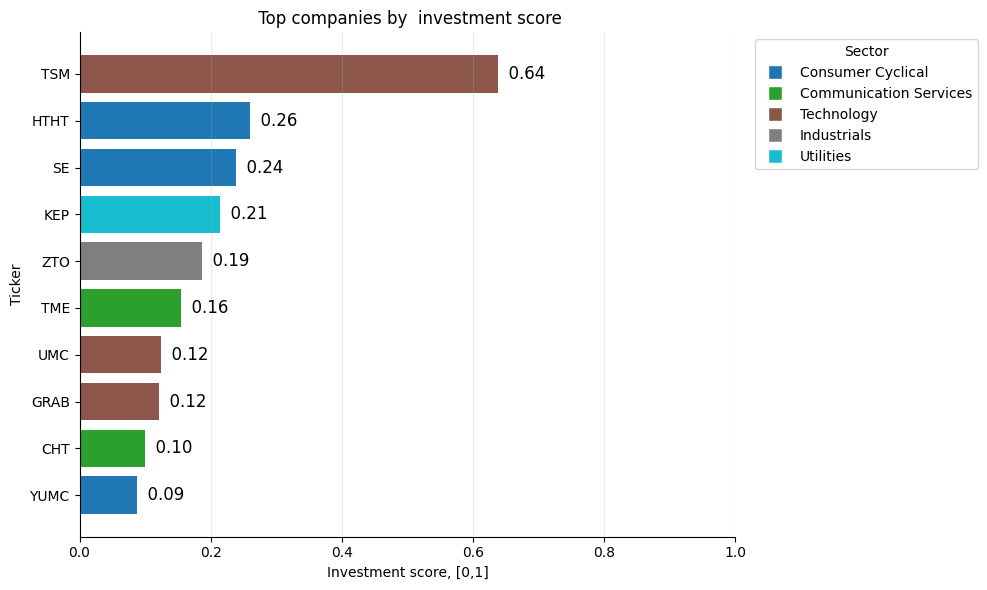

In [1473]:
#How do I choose the company?

# Create a dataset which consider all the variables regarding the Asia continent 

selected_countries = df_sample[
    df_sample['country'].isin([
        'China',
        'Taiwan',
        'Singapore',
        'South Korea',
        'Hong Kong'
    ])
]

# choose the metrics that I want to analyse 

score_columns = [
    "market_cap_b",
    "profit_margin_pct",
    "revenue_growth_pct",
    "return_on_equity_pct",
    "free_cashflow_b"
]


#Remove the missing values from the selected metrics including "symbol","company_name" and "sector"

score_df = selected_countries.dropna(subset=score_columns + ["symbol", "company_name", "sector"]).copy()

# Remove extreme values that would distort min-max scaling.

score_df = score_df[
    (score_df["market_cap_b"] >= 10) &               # exclude micro-caps
    (score_df["profit_margin_pct"].between(-20, 80)) &
    (score_df["revenue_growth_pct"].between(-50, 100)) &
    (score_df["return_on_equity_pct"].between(-100, 200)) &
    (score_df["free_cashflow_b"] > 0)             
].copy()

# Checks whether the scoring dataset is empty after applying constraints.
# If the condition is true (empty), it raises an error indicating that the thresholds may be too strict

if score_df.empty:
    raise ValueError(
        "The scoring dataset is empty after filtering. "
        "Relax the thresholds or inspect missing values in the required columns."
    )

#This function performs Min-Max normalization on a pandas Series, scaling values between 0 and 1.
#It first computes the minimum (lo) and maximum (hi) of the series.
#If all values are identical (lo == hi), normalization is not possible, so it returns a series filled with 0.5 (a neutral value).

def minmax(series):
    lo, hi = series.min(), series.max()
    return pd.Series(0.5, index=series.index) if lo == hi else (series - lo) / (hi - lo)

#Each metric is normalized using Min-Max scaling so that values are comparable on a 0–1 scale

score_df["size_score"] = minmax(score_df["market_cap_b"])
score_df["margin_score"] = minmax(score_df["profit_margin_pct"])
score_df["growth_score"] = minmax(score_df["revenue_growth_pct"])
score_df["roe_score"] = minmax(score_df["return_on_equity_pct"])
score_df["fcf_score"]= minmax(score_df["free_cashflow_b"])



#This creates a final investment score by combining all components using predefined weights.
#Weights reflect the relative importance of each factor

score_df["investment_score"] = (
    0.15  * score_df["size_score"]      +
    0.20  * score_df["margin_score"]    + # strong importance
    0.20  * score_df["growth_score"]    + # strong importance
    0.15  * score_df["roe_score"]       +
    0.15  * score_df["fcf_score"]       
)

# Keep the top 10 companies by investment score.
shortlist = score_df.sort_values("investment_score", ascending=False).head(10).copy()


#set up ascending = True so that the highest values appears at the top of the chart
plot_shortlist = shortlist.sort_values("investment_score", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Assign one color per sector.

sectors = plot_shortlist["sector"].fillna("Unknown").unique()
palette = plt.cm.tab10(np.linspace(0, 1, len(sectors)))  
sector_to_color = dict(zip(sectors, palette))             
bar_colors = plot_shortlist["sector"].fillna("Unknown").map(sector_to_color)


# symbol y-axis and investment_score [0,1] x-axis

ax.barh(plot_shortlist["symbol"], plot_shortlist["investment_score"], color=bar_colors)

ax.set_title(" Top companies by  investment score")
ax.set_xlabel("Investment score, [0,1]")
ax.set_ylabel("Ticker")

# Leave 15 % of extra space on the right so bar labels don't get clipped.

ax.set_xlim(0, max(1, plot_shortlist["investment_score"].max() * 1.15))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

annotate_hbar(ax, fmt="{:.2f}")

# Build a custom legend manually 

legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=sector,
               markerfacecolor=color, markersize=10)
    for sector, color in sector_to_color.items()
]
ax.legend(handles=legend_handles, title="Sector", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#I selected Taiwan Semiconductor Manufacturing Company (TSM) because it achieved the highest investment score (0.64), 
# ranking it as the strongest performer across size, profitability, growth, return on equity, and cash flow.


## Step 2: Build peer groups 

In [1474]:
# A: Same Industry

TSM_industry = df_sample.loc[df_sample['symbol'] == 'TSM', 'industry'].iloc[0]

print('---The TSM industry is {} ---'.format(TSM_industry))

# Filter the dataset to include only companies within the same industry as TSM

selected_industry = df_sample[df_sample['industry'] == TSM_industry]

# Remove the rows where the market_cap_b column is equal to Nan 

top10 = selected_industry.dropna(subset =["market_cap_b"]).nlargest(10, "market_cap_b").copy()

# nlargest() returns the observations already sorted in descending order by market capitalization.

print(top10)


---The TSM industry is Semiconductors ---
     symbol                                       company_name      sector  \
1967   NVDA                                 NVIDIA Corporation  Technology   
2759    TSM  Taiwan Semiconductor Manufacturing Company Lim...  Technology   
277    AVGO                                      Broadcom Inc.  Technology   
1850     MU                            Micron Technology, Inc.  Technology   
146     AMD                       Advanced Micro Devices, Inc.  Technology   
1430   INTC                                  Intel Corporation  Technology   
218     ARM                                   Arm Holdings plc  Technology   
2783    TXN                     Texas Instruments Incorporated  Technology   
2249   QCOM                              QUALCOMM Incorporated  Technology   
48      ADI                               Analog Devices, Inc.  Technology   

            industry         country    market_cap  return_on_assets  \
1967  Semiconductors   Unit

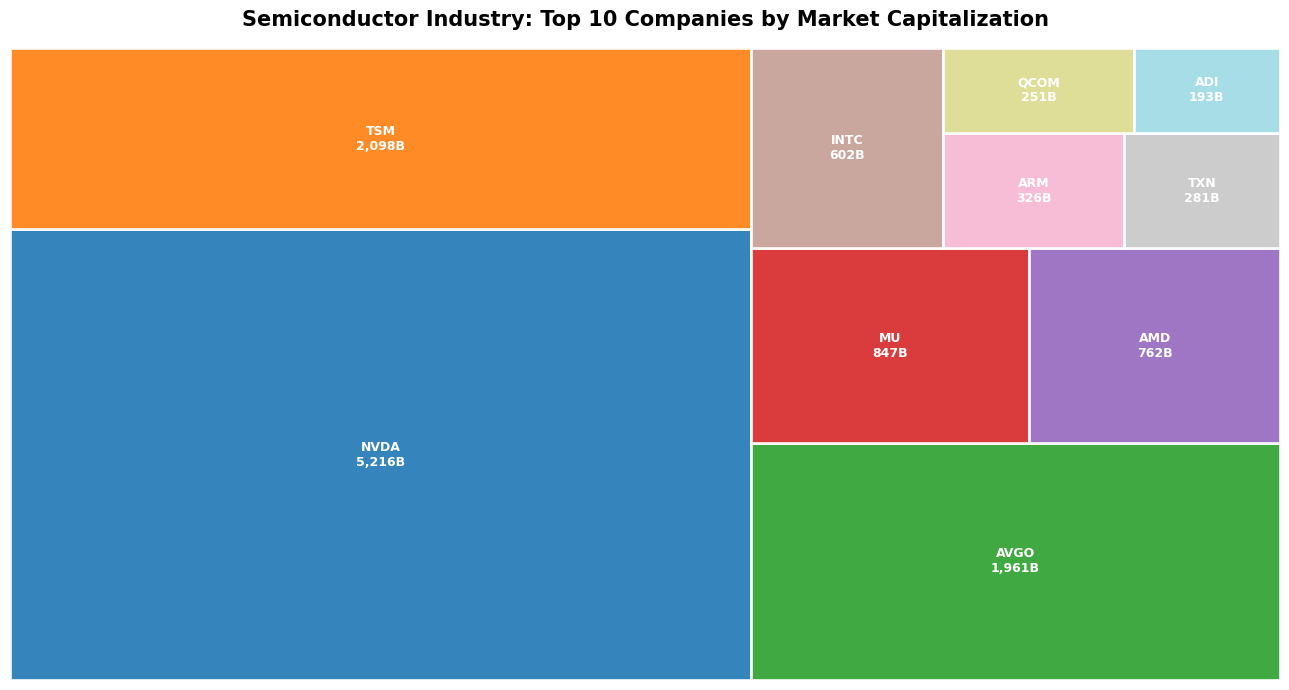

In [1475]:
import squarify


#This line creates a new column called company_name_clean by taking the values from company_name 
# and replacing any missing values (NaN) with the string "Unknown".

top10["company_name_clean"] = top10["company_name"].fillna("Unknown")

# Create color mapping for each company

companies = top10["company_name_clean"].unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(companies)))
company_to_color = dict(zip(companies, palette))

# Map colors to companies

colors = top10["company_name_clean"].map(company_to_color)

# Create labels for each rectangle (symbol + market cap_b)

labels = [
    f"{symbol}\n{market_cap:,.0f}B"
    for symbol, market_cap in zip(top10["symbol"], top10["market_cap_b"])
]

fig, ax = plt.subplots(figsize=(13, 7))


# Draw treemap
squarify.plot(
    sizes=top10["market_cap_b"],
    label=labels,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=2,
    text_kwargs={
        "fontsize": 9,
        "color": "white",
        "weight": "bold"
    },
    ax=ax
)


ax.set_title(
    "Semiconductor Industry: Top 10 Companies by Market Capitalization",
    fontsize=15,
    fontweight="bold",
    pad=16
)


# Remove axes 

ax.axis("off")

plt.tight_layout()
plt.show()

In [1476]:
# B: Same geographic group, select all the companies which belong to Asia continent

# nlargest() returns the observations already sorted in descending order by market capitalization.
# dropna(subset = ["market_cap_b"]) removes the rows where market_cap_b is equal to Nan 

top10_1 = selected_countries.dropna(subset = ["market_cap_b"]).nlargest(10, "market_cap_b").copy()
print(top10_1)



     symbol                                       company_name  \
2759    TSM  Taiwan Semiconductor Manufacturing Company Lim...   
2609    STX                    Seagate Technology Holdings plc   
245     ASX                   ASE Technology Holding Co., Ltd.   
2434     SE                                        Sea Limited   
2819    UMC                United Microelectronics Corporation   
1511     KB                            KB Financial Group Inc.   
576     CHT                         Chunghwa Telecom Co., Ltd.   
2162    PKX                                POSCO Holdings Inc.   
3062    ZTO                          ZTO Express (Cayman) Inc.   
347    BEKE                                   KE Holdings Inc.   

                      sector                        industry      country  \
2759              Technology                  Semiconductors       Taiwan   
2609              Technology               Computer Hardware    Singapore   
245               Technology              

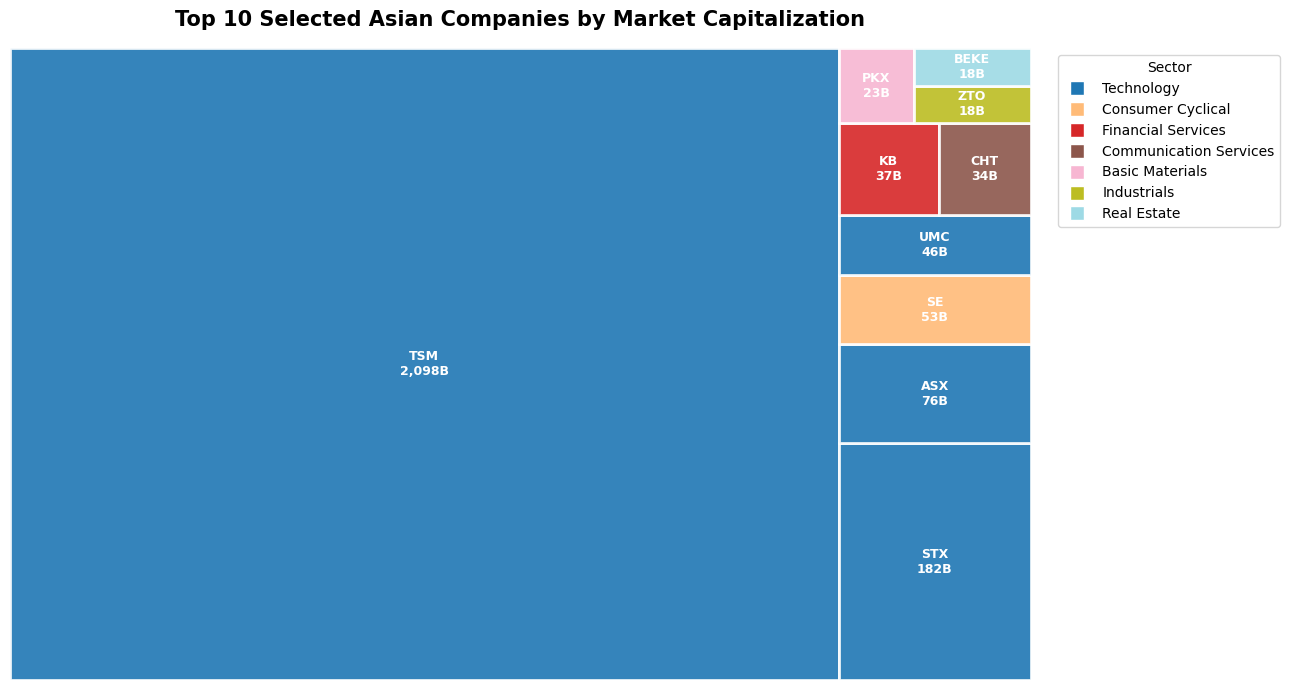

In [1477]:


top10_1["sector_clean"] = top10_1["sector"].fillna("Unknown")

# Create a color map for sectors.
# Each sector receives one color from the tab20 palette.

sectors = top10_1["sector_clean"].unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_to_color = dict(zip(sectors, palette))

# Assign one color to each company based on its sector.

colors = top10_1["sector_clean"].map(sector_to_color)


labels = [
    f"{symbol}\n{market_cap:,.0f}B"
    for symbol, market_cap in zip(top10_1["symbol"], top10_1["market_cap_b"])
]

fig, ax = plt.subplots(figsize=(13, 7))



# Draw treemap
squarify.plot(
    sizes=top10_1["market_cap_b"],
    label=labels,
    color=colors,
    alpha=0.9,
    edgecolor="white",
    linewidth=2,
    text_kwargs={
        "fontsize": 9,
        "color": "white",
        "weight": "bold"
    },
    ax=ax
)


ax.set_title(
     "Top 10 Selected Asian Companies by Market Capitalization",
    fontsize=15,
    fontweight="bold",
    pad=16
)


# Remove axes 

ax.axis("off")

# Create a custom legend for sectors.
# We build it manually because the colors were assigned from a dictionary.

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label=sector,
        markerfacecolor=color,
        markersize=10
    )
    for sector, color in sector_to_color.items()
]

# Place the legend outside the chart on the right.
# This keeps the treemap area clean.

ax.legend(
    handles=legend_handles,
    title="Sector",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)



plt.tight_layout()
plt.show()

In [1478]:
# Group C: Closest Market Capitalization 


TSM_market_cap_b= df_sample.loc[df_sample['symbol'] == 'TSM', 'market_cap_b'].iloc[0]
print('--- TSM market_cap_b is {:.2f} ---'.format(TSM_market_cap_b))

# add a new column
df_sample['distance_to_TSM'] = abs(df_sample['market_cap_b'] - TSM_market_cap_b)

# Missing values do not impact the identification of the closest companies to TSM,
# as the nsmallest() function automatically excludes NaN values when performing the ranking.

closest_to_TSM = df_sample.nsmallest(10,'distance_to_TSM').sort_values("distance_to_TSM",ascending = False).copy()

print(closest_to_TSM)



--- TSM market_cap_b is 2098.03 ---
     symbol                                       company_name  \
1634    LLY                              Eli Lilly and Company   
2983    WMT                                       Walmart Inc.   
431   BRK-A                            Berkshire Hathaway Inc.   
432   BRK-B                            Berkshire Hathaway Inc.   
1828   MSFT                              Microsoft Corporation   
168    AMZN                                   Amazon.com, Inc.   
1749   META                               Meta Platforms, Inc.   
2758   TSLA                                        Tesla, Inc.   
277    AVGO                                      Broadcom Inc.   
2759    TSM  Taiwan Semiconductor Manufacturing Company Lim...   

                      sector                        industry        country  \
1634              Healthcare    Drug Manufacturers - General  United States   
2983      Consumer Defensive                 Discount Stores  United States   


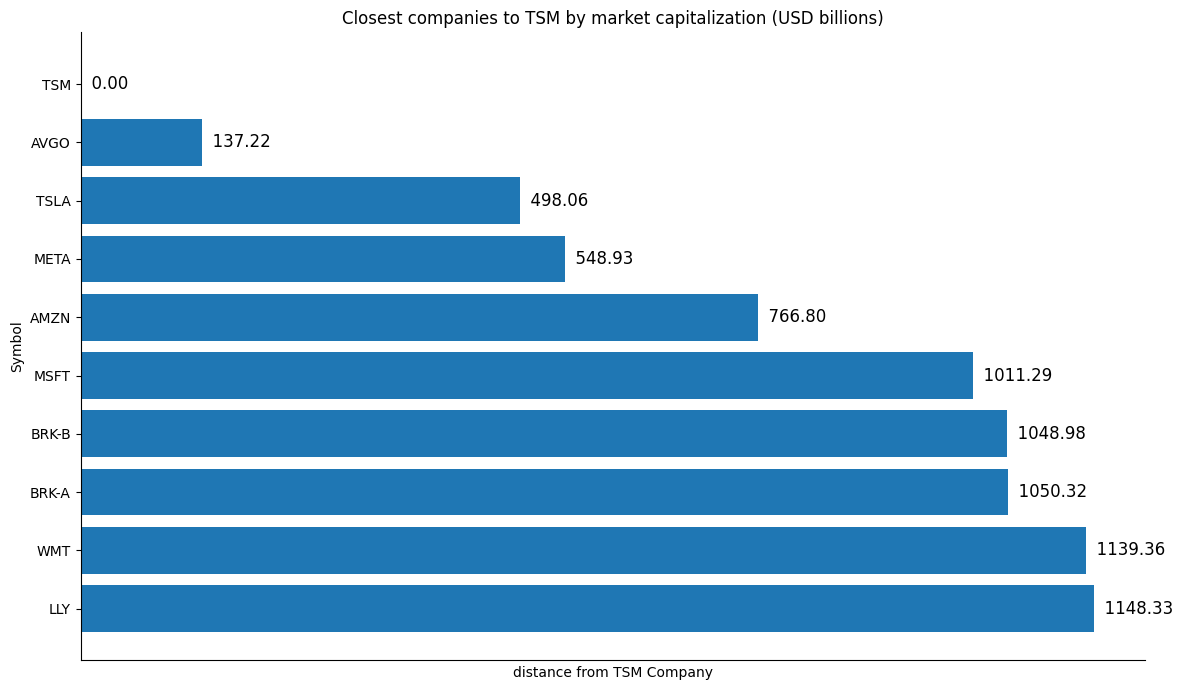

In [1479]:

fig, ax = plt.subplots(figsize=(12, 7))

# Use the percentage column instead of the market cap in billions.
ax.barh(
     closest_to_TSM["symbol"],
    closest_to_TSM["distance_to_TSM"],
  
)

ax.set_title("Closest companies to TSM by market capitalization (USD billions)")

# Remove the X-axis label because values are shown directly on the bars.
ax.set_xlabel("distance from TSM Company")
ax.set_ylabel("Symbol")

# Remove the vertical grid lines.
ax.grid(False)

# Remove X-axis ticks and tick labels.
# This makes the chart cleaner and more report-like.
ax.tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False
)


# Keep  custom function to clean the other spines.
clean_spines(ax)

# Add percentage labels to the bars.
annotate_hbar(ax, fmt="{:.2f}")

plt.tight_layout()

plt.show()


## Step 3:  Is the company profitable? 

In [1480]:
# Remove missing values from the datasets regarding the variables: symbol, profit_margin_pct, ROE(%)and ROA(%)

top10_clean = top10[['symbol','profit_margin_pct','return_on_equity_pct','return_on_assets_pct']].dropna()

top10_1_clean = top10_1[['symbol','profit_margin_pct','return_on_equity_pct','return_on_assets_pct']].dropna()

closest_to_TSM_clean = closest_to_TSM[['symbol','profit_margin_pct','return_on_equity_pct','return_on_assets_pct']].dropna()


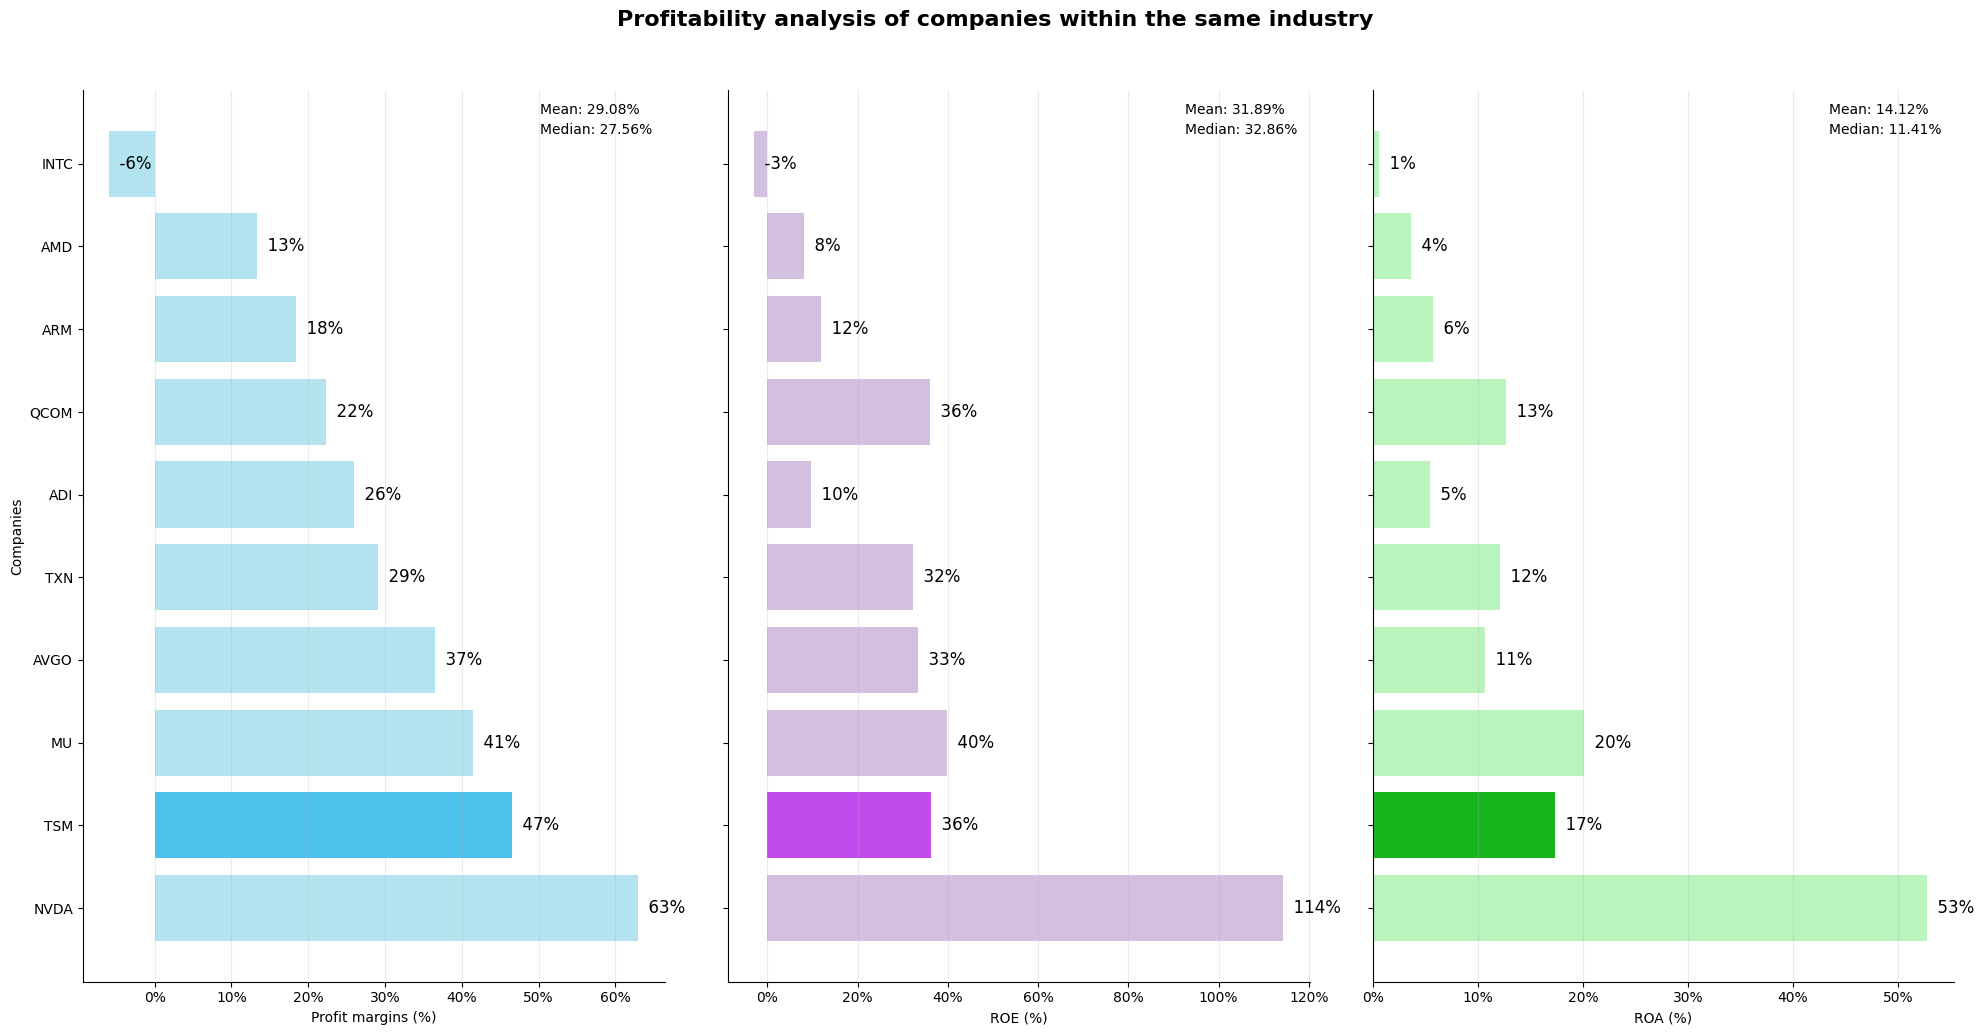

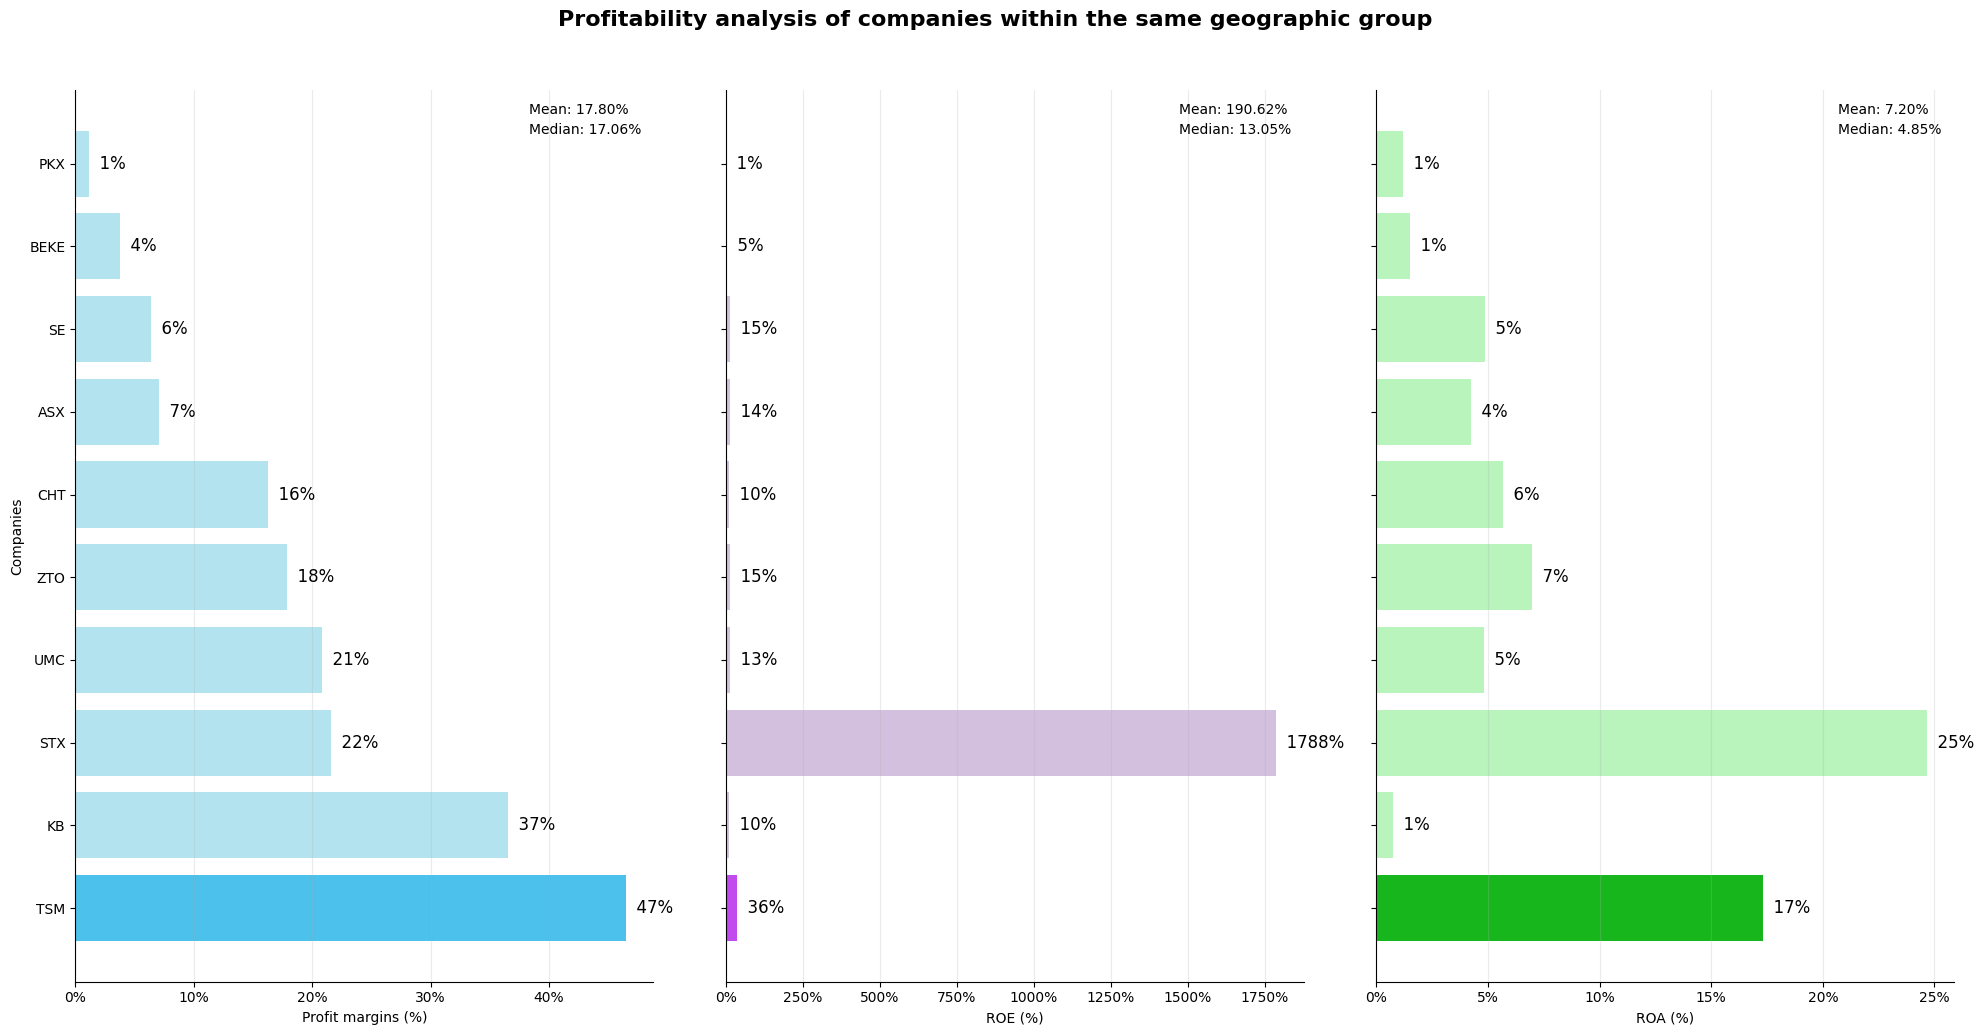

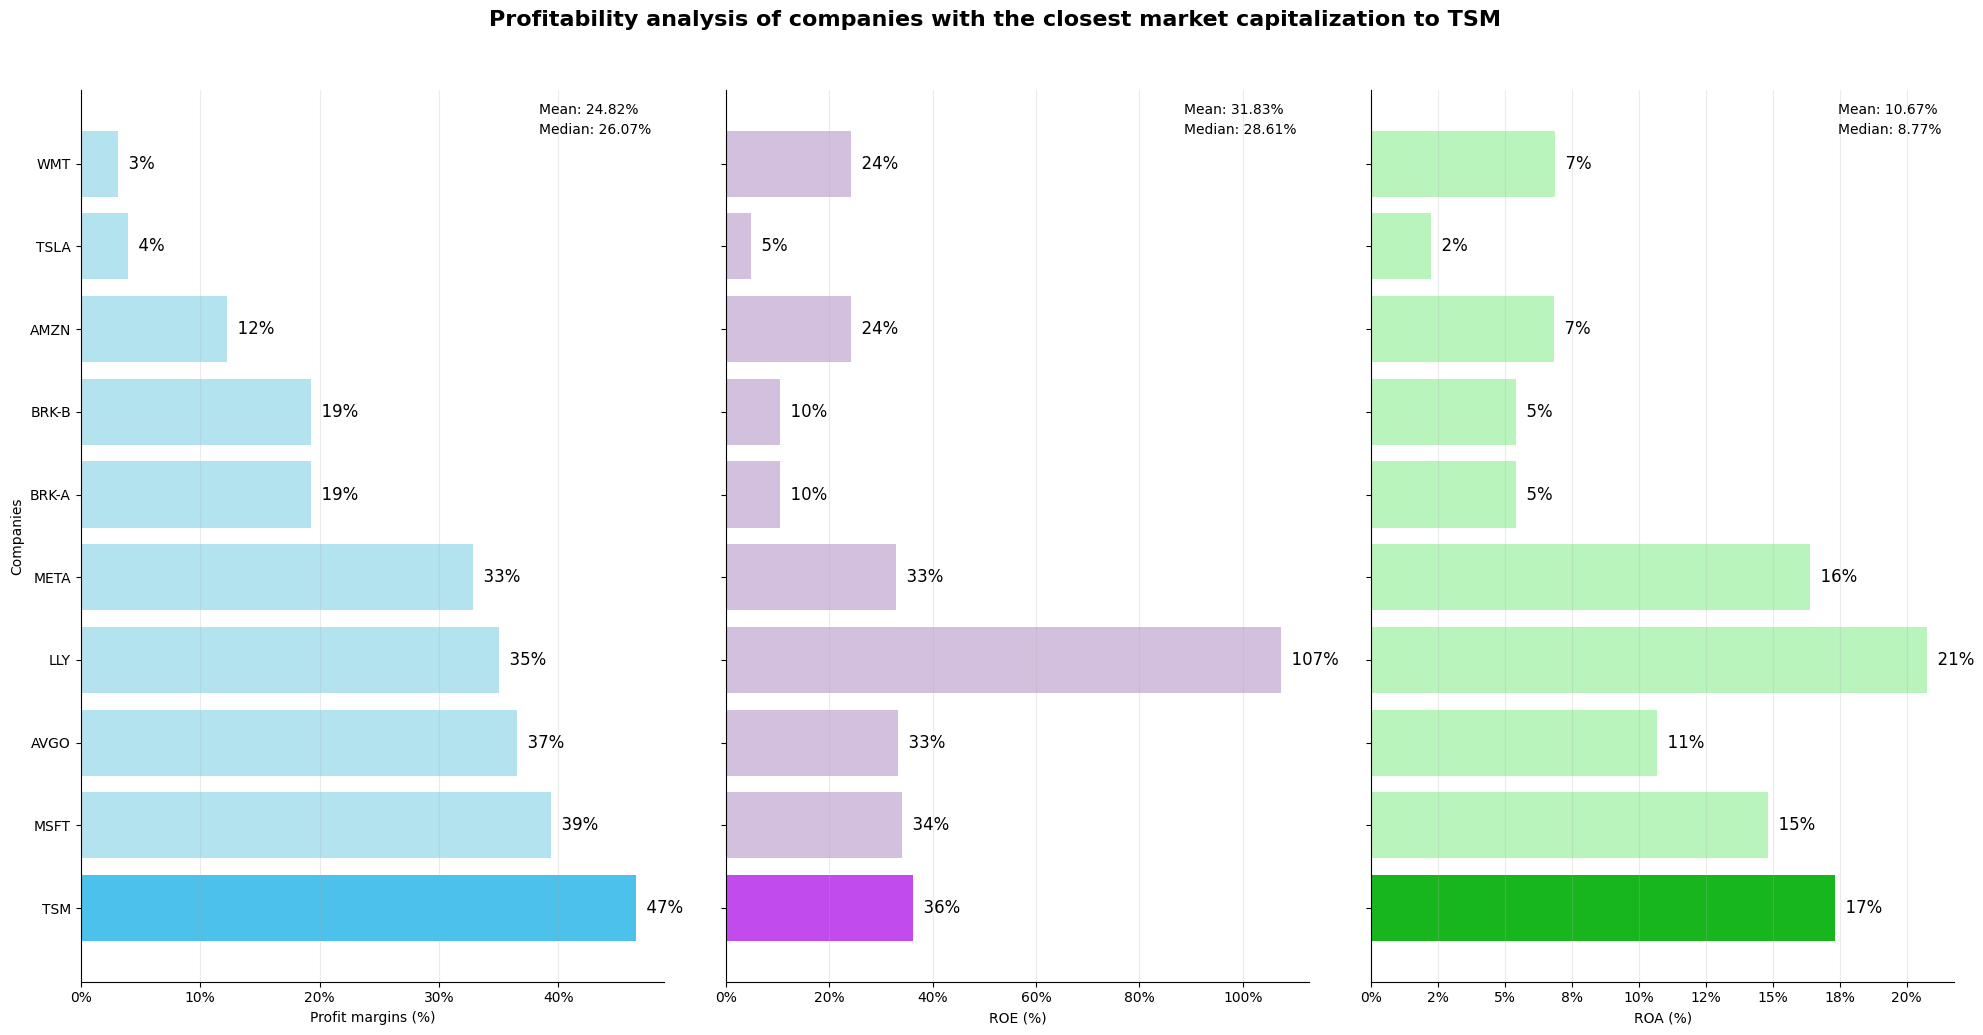

In [1481]:

# First of all I create a dataset to avoid of repeating three times the same code 

datasets = [
    (top10_clean, "Profitability analysis of companies within the same industry"),
    (top10_1_clean, "Profitability analysis of companies within the same geographic group"),
    (closest_to_TSM_clean, "Profitability analysis of companies with the closest market capitalization to TSM")
]

# set up the target to highlight the selected company (TSM)
target = "TSM"

# Loop through each dataset and its corresponding title
for dataset, figure_title in datasets:
# Set "symbol" as index and sort by profit margin in descending order
    grouped = dataset.set_index("symbol").sort_values(
        "profit_margin_pct",
        ascending= False
    )

# create a chart for each metric (profit_margin_pct, return_on_equity_pct and return_on_assets_pct)
    fig, ax = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(20, 10),
        sharey=True
    )

# set the axis for each metric
    ax_prof = ax[0]
    ax_ROE = ax[1]
    ax_ROA = ax[2]

    # PROFIT MARGIN
    # compute median e mean releted to the variable profit_margin_pct for both DataFrames 

    median_value = grouped["profit_margin_pct"].median()
    mean_value = grouped["profit_margin_pct"].mean()

    # # Define bar colors by mapping each company:
    # the target company (TSM) is highlighted in a different color only if its
    # profit margin is greater than or equal to the median value,
    # while all other companies are assigned a default color.

    colors_prof = grouped.index.map(
        lambda x: "#4BC1EC"
        if x == target and grouped.loc[x, "profit_margin_pct"] >= median_value
        else "#14A7D051"
    )

    ax_prof.barh(
        grouped.index, #symbol --> y-axis
        grouped["profit_margin_pct"], # x-axis
        color=colors_prof
    )
    # Create custom legend entries to display the mean and median values  of the variable, without showing actual plotted lines.

    legend_elements = [
        Line2D([0], [0], color="none",
               label=f"Mean: {mean_value:.2f}%"),
        Line2D([0], [0], color="none",
               label=f"Median: {median_value:.2f}%")
    ]

   
    ax_prof.set_xlabel("Profit margins (%)")
    ax_prof.set_ylabel("Companies")
    ax_prof.grid(axis="x", alpha=0.25)
    ax_prof.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax_prof.legend(handles=legend_elements, frameon=False)
    annotate_hbar(ax_prof, fmt="{:.0f}%")
    clean_spines(ax_prof)

# Apply the same logic to the other variables: ROE and ROA
    # ROE
    median_value_1 = grouped["return_on_equity_pct"].median()
    mean_value_1 = grouped["return_on_equity_pct"].mean()

    colors_roe = grouped.index.map(
        lambda x: "#C14BEC"
        if x == target and grouped.loc[x, "return_on_equity_pct"] >= median_value_1
        else "#9B72B772"
    )

    ax_ROE.barh(
        grouped.index,
        grouped["return_on_equity_pct"],
        color=colors_roe
    )

    legend_elements = [
        Line2D([0], [0], color="none",
               label=f"Mean: {mean_value_1:.2f}%"),
        Line2D([0], [0], color="none",
               label=f"Median: {median_value_1:.2f}%")
    ]

  
    ax_ROE.set_xlabel("ROE (%)")
    ax_ROE.grid(axis="x", alpha=0.25)
    ax_ROE.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax_ROE.legend(handles=legend_elements, frameon=False)
    annotate_hbar(ax_ROE, fmt="{:.0f}%")
    clean_spines(ax_ROE)

    # ROA
    median_value_2 = grouped["return_on_assets_pct"].median()
    mean_value_2 = grouped["return_on_assets_pct"].mean()

    colors_roa = grouped.index.map(
        lambda x: "#18B61D"
        if x == target and grouped.loc[x, "return_on_assets_pct"] >= median_value_2
        else "#07DB1649"
    )

    ax_ROA.barh(
        grouped.index,
        grouped["return_on_assets_pct"],
        color=colors_roa
    )

    legend_elements = [
        Line2D([0], [0], color="none",
               label=f"Mean: {mean_value_2:.2f}%"),
        Line2D([0], [0], color="none",
               label=f"Median: {median_value_2:.2f}%")
    ]


    ax_ROA.set_xlabel("ROA (%)")
    ax_ROA.grid(axis="x", alpha=0.25)
    ax_ROA.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax_ROA.legend(handles=legend_elements, frameon=False)
    annotate_hbar(ax_ROA, fmt="{:.0f}%")
    clean_spines(ax_ROA)

    fig.suptitle(
        figure_title,
        fontsize=16,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()
    plt.show()

 # Group A - Profitability analysis of companies within the same industry

# Companies generally show a positive trend in profit margins, except for INTC (-6%).
# The strongest companies in terms of profit margins are NVDA (63%), TSM (47%) and MU (41%),
# all exceeding the median threshold.

# Companies also show a moderate trend in ROE.
# INTC reports a negative performance (-3%), while NVDA shows a particularly strong positive ROE.
# The selected company (TSM) achieves a moderate-to-high ROE of 36%, exceeding the median threshold. 

# The ROA variable highlights an overall positive trend across companies, with NVDA being the strongest performer (53%).
# TSM shows a positive moderate performance (17%), exceeding the median threshold.

# Evaluating companies within the same industry (semiconductors), NVDA is the strongest company in terms of profitability,
# followed by TSM (an Asian company) and MU.



# Group B - Profitability analysis of companies within the same geographic group

# The selected company shows strong profitability performance: profit margin (47%), ROE (36%), and ROA (17%),
# with all metrics exceeding the median.

# The median is used as the benchmark instead of the mean due to its robustness to extreme values.
#The distribution highlights the presence of an extreme outlier in ROE (1788%) for STX,
# which significantly distorts the mean and justifies the use of the median.

# Overall, the selected company is positioned above the typical performance level within its geographic peer group.


#Group C - Profitability analysis of companies with the closest market capitalization to TSM
#the analysis focuses on all the companies which are similar to TSM company in size 

# LLY is the strongest company in terms of profitability, achieving a ROE of 107% 
# and also showing strong performance in the other two metrics: profit margin (35%) and ROA (21%).

# It is followed by TSM, which shows robust profitability metrics compared to the other companies.


## Step 4: Is the company expensive or cheap?

In [1482]:
#GROUP A

top10_clean_1 = top10[['symbol','pe_trailing','price_to_book']].dropna().copy()

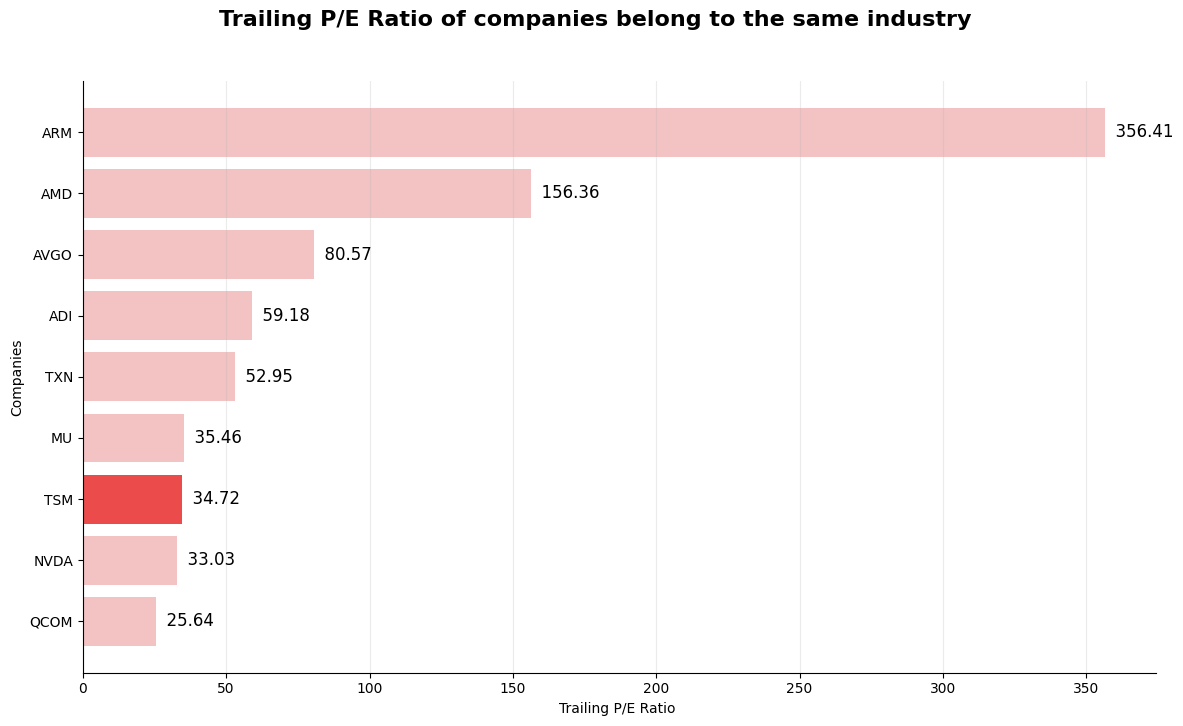

In [1483]:

# Sort ascending for a horizontal bar chart.
# This places the largest value at the top after inverting the y-axis.

top10_clean_1 = top10_clean_1.sort_values("pe_trailing",ascending = True)
fig, ax = plt.subplots(figsize=(12, 7))

colors_pe_trailing= top10_clean_1["symbol"].map(
        lambda x: "#EC4B4BFF"
        if x == target 
        else "#D0141441"
    )

ax.barh(
        top10_clean_1['symbol'], 
        top10_clean_1["pe_trailing"], # x-axis
        color=colors_pe_trailing
    )


ax.set_xlabel("Trailing P/E Ratio ")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)
annotate_hbar(ax, fmt="{:.2f}")
clean_spines(ax)

fig.suptitle("Trailing P/E Ratio of companies belong to the same industry",
        fontsize=16,
        fontweight="bold",
        y=1.03
    )

plt.tight_layout()
plt.show()

#The trailing P/E ratio measures a company's current share price relative to its earnings per share (EPS) over the past 12 months.
# it reflects how much investors are willing to pay for each unit of earnings and is commonly used as an indicator of market expectations.

# Within the industry, ARM (UK-based) shows the highest valuation level(356.41), followed by AMD (US-based) which achieved a score of 156.36 and AVGO(80.57),
# suggesting a huge growth expectations for these firms.

# TSM presents a moderate P/E ratio of 34.72, indicating a strong growth expectations. 


In [1484]:
df_sample.loc[df_sample["symbol"] == "TSM", "country"]

2759    Taiwan
Name: country, dtype: str

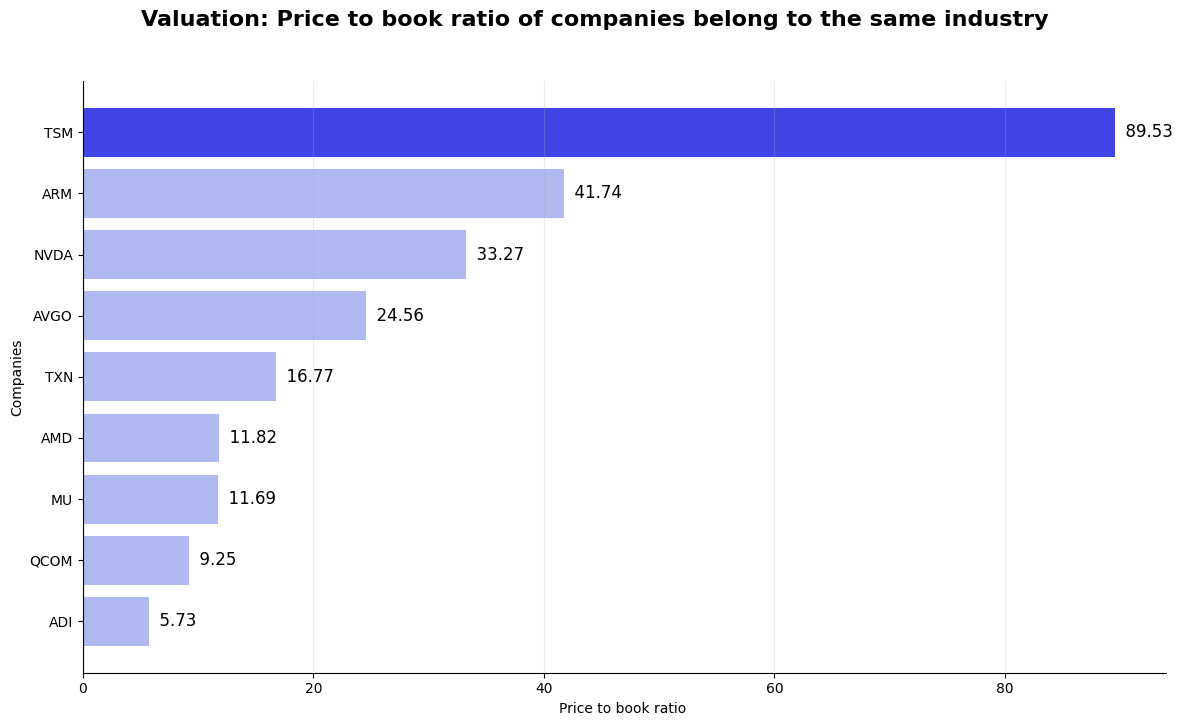

In [1485]:
top10_clean_1 = top10_clean_1.sort_values("price_to_book",ascending = True)
fig, ax = plt.subplots(figsize=(12, 7))


colors_price_to_book= top10_clean_1['symbol'].map(
        lambda x: "#0408DDC0"
        if x == target 
        else "#142DD056"
    )

ax.barh(
        top10_clean_1['symbol'], #symbol --> y-axis
        top10_clean_1["price_to_book"], # x-axis
        color=colors_price_to_book
    )


ax.set_xlabel("Price to book ratio ")
ax.set_ylabel("Companies")
ax.grid(axis="x", alpha=0.25)
annotate_hbar(ax, fmt="{:.2f}")
clean_spines(ax)

fig.suptitle("Valuation: Price to book ratio of companies belong to the same industry",
        fontsize=16,
        fontweight="bold",
        y=1.03
    )

plt.tight_layout()
plt.show()


#A high P/B ratio means that investors value the company more highly than its book value, often because they expect strong future growth.
#A low P/B ratio may indicate that the company is undervalued or that the market has low expectations regarding its future performance.

# Observing the chart,  TSM firm  achieves the highest score (89.53), this suggests that the market has strong growth expectations for the company.

# Unlike the previous metric, this indicator is based on the company’s equity rather than its profitability, focusing on net assets instead of earnings.

## Step 5: Is the company growing?

In [1486]:
#Remove missing values and  outliers 

#GROUP A

revenue_growth_clean  =top10.dropna(subset=["revenue_growth_pct"])

df_clean = revenue_growth_clean[
    revenue_growth_clean["revenue_growth_pct"].between(
        revenue_growth_clean["revenue_growth_pct"].quantile(0.05),
        revenue_growth_clean["revenue_growth_pct"].quantile(0.95)
    )
]

#GROUP B
revenue_growth_clean_1  =top10_1.dropna(subset=["revenue_growth_pct"])

df_clean_1 = revenue_growth_clean_1[
     revenue_growth_clean_1["revenue_growth_pct"].between(
          revenue_growth_clean_1["revenue_growth_pct"].quantile(0.05),
          revenue_growth_clean_1["revenue_growth_pct"].quantile(0.95)
    )
]

#GROUP C

revenue_growth_clean_2  =  closest_to_TSM.dropna(subset=["revenue_growth_pct"])

df_clean_2 = revenue_growth_clean_2[
     revenue_growth_clean_2['revenue_growth_pct'].between(
          revenue_growth_clean_2["revenue_growth_pct"].quantile(0.05),
        revenue_growth_clean_2["revenue_growth_pct"].quantile(0.95)

    )
]


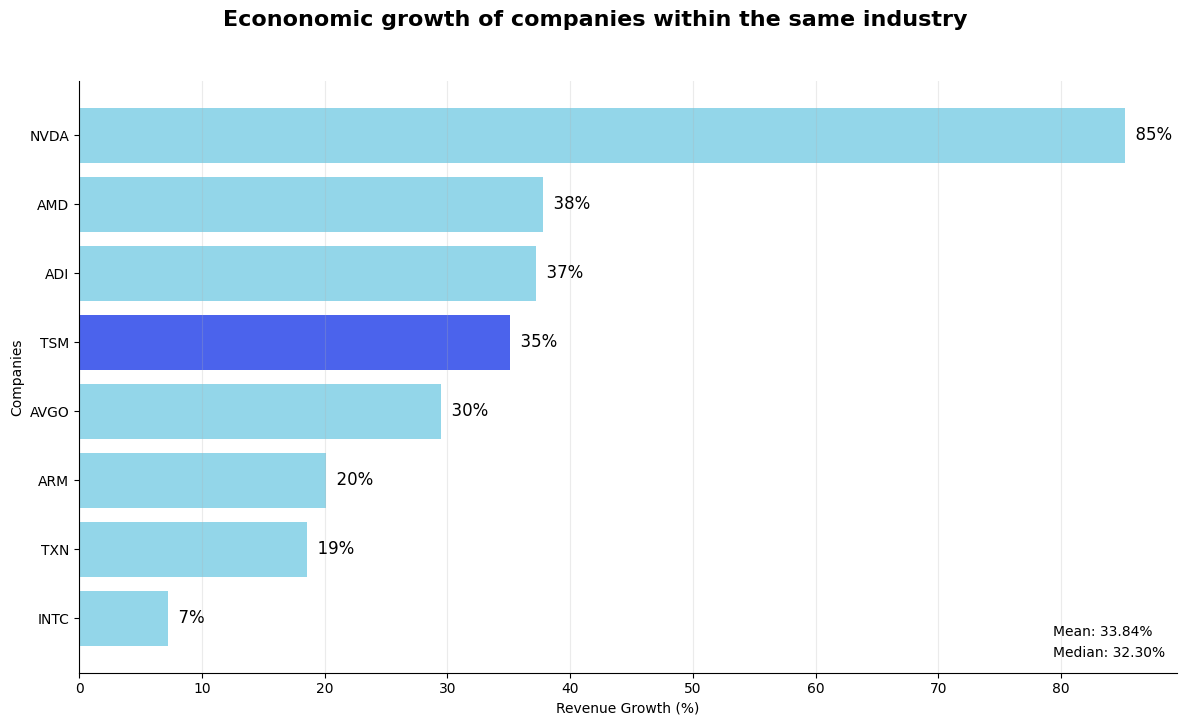

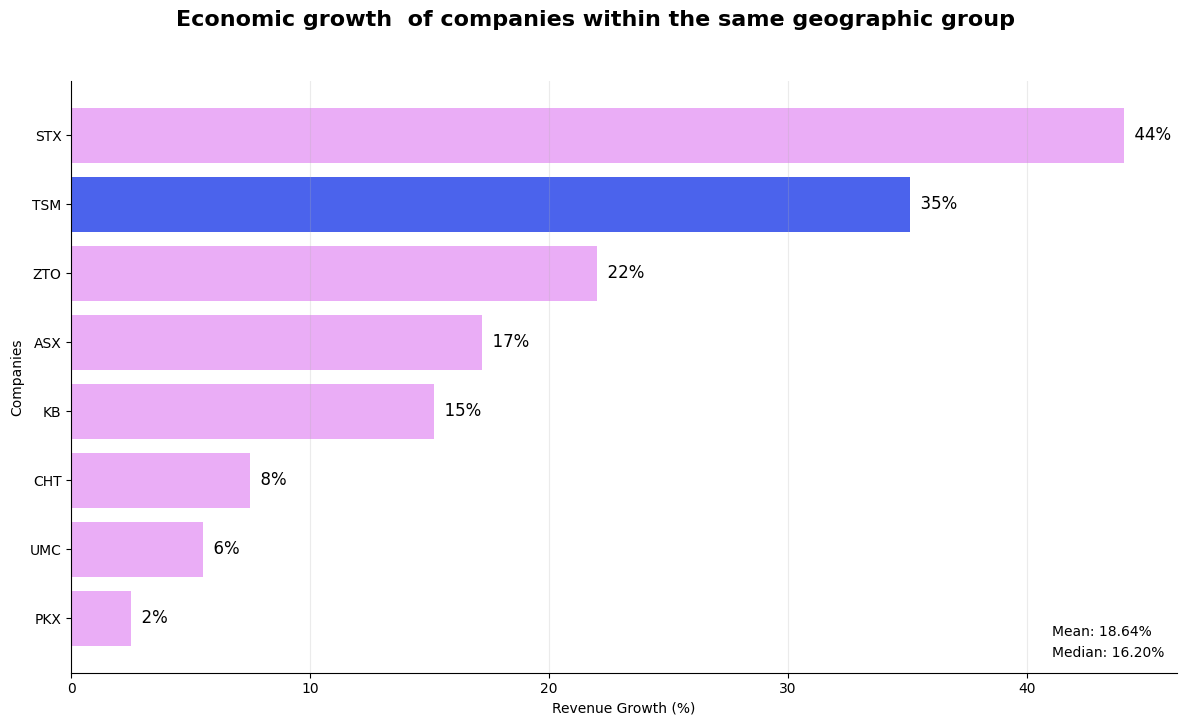

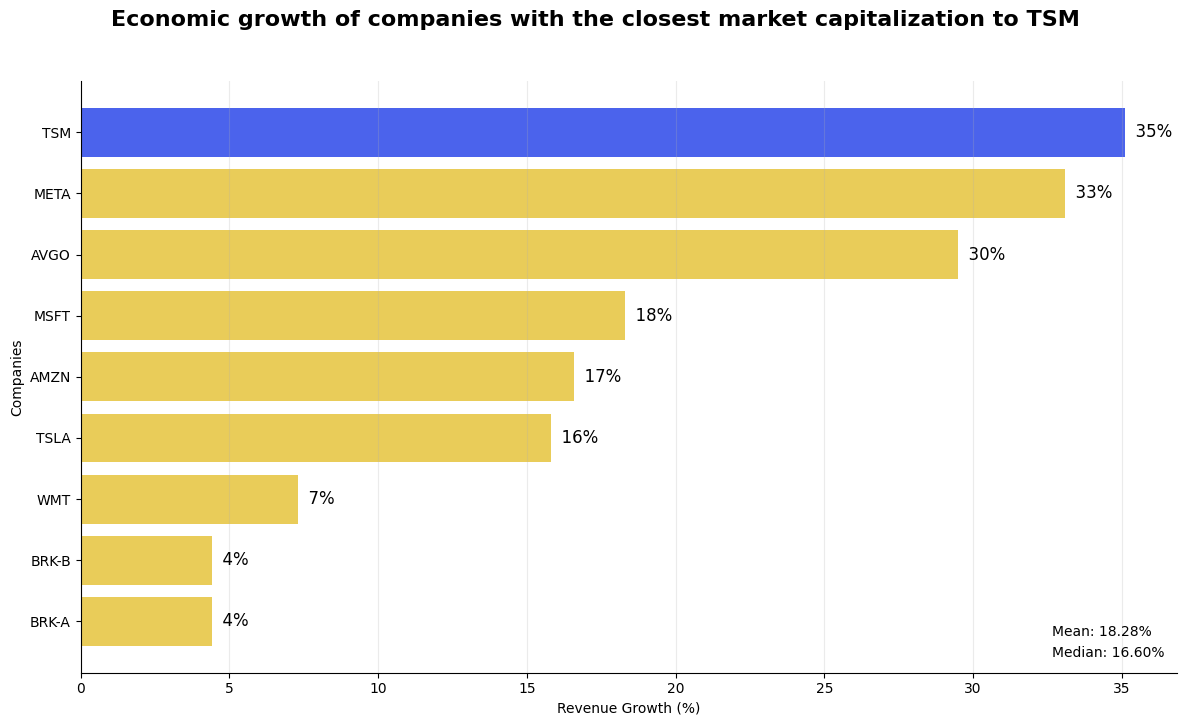

In [1487]:

datasets_1 = [
    (df_clean, "Econonomic growth of companies within the same industry"),
    (df_clean_1, "Economic growth  of companies within the same geographic group"),
    (df_clean_2, "Economic growth of companies with the closest market capitalization to TSM")
]

# set up the target to highlight the selected company 
target = "TSM"

#create a list of colors for each chart
base_colors = ["#14A7D075", "#D14BEC74", "#E2BB20BE"]

# Loop through datasets
for i,(dataset_1, figure_title_1) in enumerate(datasets_1):

    grouped_1 = dataset_1.set_index("symbol").sort_values(
        "revenue_growth_pct",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(12, 7))
    
    # compute the median and the mean for each dataset 

    median_revenue_growth = grouped_1["revenue_growth_pct"].median()
    mean_revenue_growth = grouped_1["revenue_growth_pct"].mean()

    #set a condition to highlight the selected company if it achieves a score greater than the median valie 
    colors_growth = grouped_1.index.map(
        lambda x: "#4B63EC"
        if x == target and grouped_1.loc[x, "revenue_growth_pct"] >= median_revenue_growth
        else  base_colors[i]
    )

    ax.barh(
        grouped_1.index,
        grouped_1["revenue_growth_pct"],
        color=colors_growth
    )

    legend_elements = [
        Line2D([0], [0], color="none",
               label=f"Mean: {mean_revenue_growth:.2f}%"),
        Line2D([0], [0], color="none",
               label=f"Median: {median_revenue_growth:.2f}%")
    ]

   
    ax.set_xlabel("Revenue Growth (%)")
    ax.set_ylabel("Companies")
    ax.grid(axis="x", alpha=0.25)

    ax.legend(handles=legend_elements, frameon=False)
    annotate_hbar(ax, fmt="{:.0f}%")
    clean_spines(ax)

    fig.suptitle(
        figure_title_1,
        fontsize=16,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()
    plt.show()


# Revenue growth measures the percentage change in a company's revenue from one period to another, indicating its ability to expand sales and generate more income.

# Group A - Revenue growth of companies within the same industry

# Firms show a generally positive trend in revenue growth.
# The strongest companies in terms of revenue growth are NVDA (85%), followed by AMD (38%), ADI (37%), and TSM (35%).
# those companies exceed the median threshold.
# In the first chart, the mean value is close to the median, suggesting there are no major outliers that could distort the results.


# Group B - Revenue growth of companies within the same geographic group

# The strongest companies are STX (44%), followed by TSM, both above the median value, indicating a stronger economic expansion phase compared to other Asian companies.
# In the second graph, there is also no significant difference between the mean and median values, suggesting the analysis is reliable.


# Group C - Revenue growth of companies with the closest market capitalization to TSM

# This analysis focuses on companies similar in size to TSM.
# TSM is the strongest company in terms of revenue growth followed by META (33%) and AVGO (30%).

## Step 6: Is the company financially solid?

In [1488]:
debt_to_equity_clean  =top10[["symbol","debt_to_equity"]].dropna()

free_cashflow_clean  = top10[["symbol","free_cashflow_b"]].dropna()

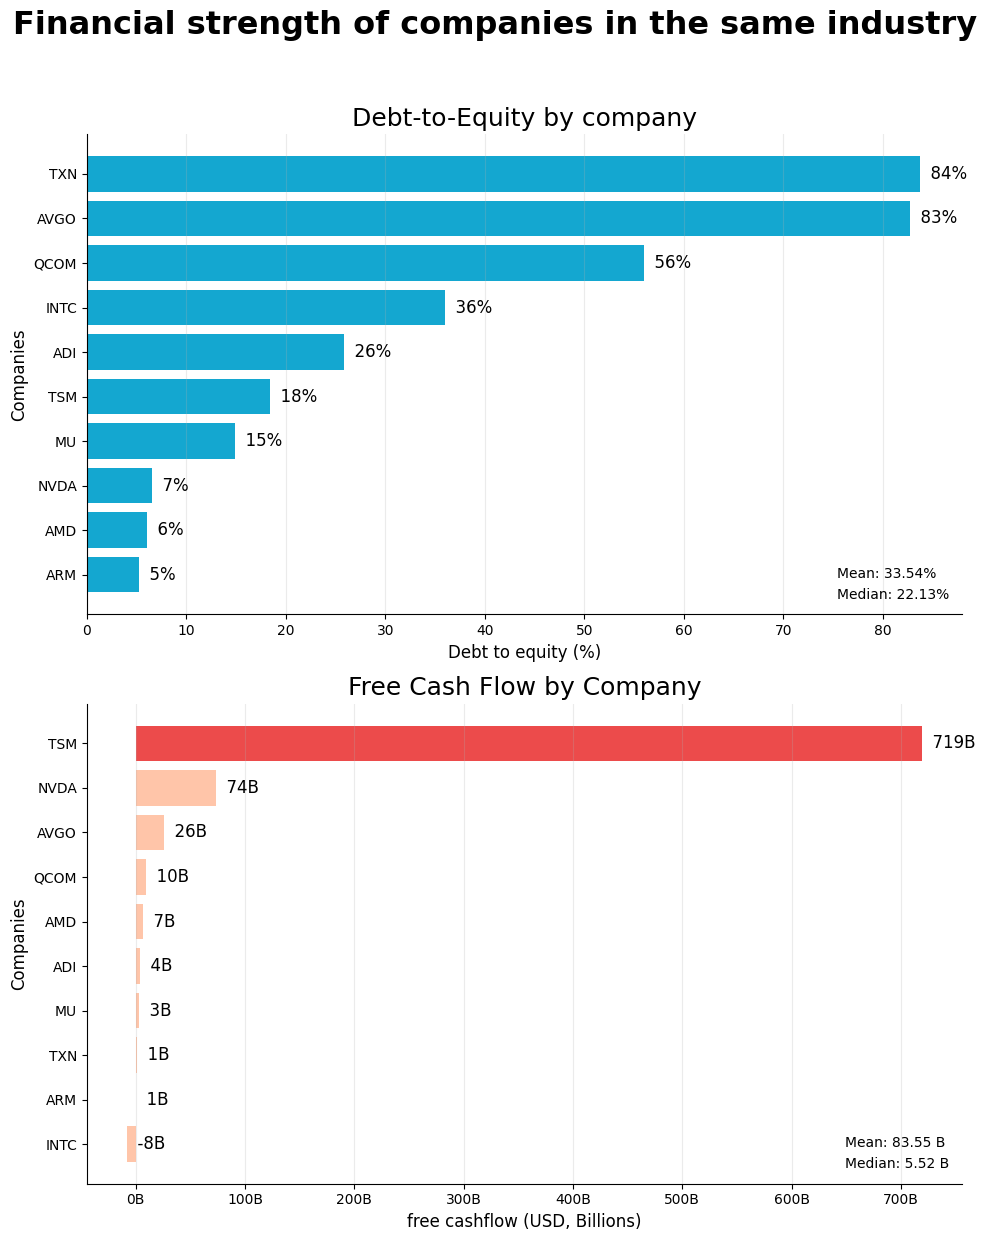

In [1489]:
debt_to_equity_clean = debt_to_equity_clean.set_index("symbol").sort_values("debt_to_equity", ascending = True)
free_cashflow_clean = free_cashflow_clean.set_index("symbol").sort_values("free_cashflow_b", ascending = True)
target = "TSM"


# create a chart for each metric (profit_margin_pct, return_on_equity_pct and return_on_assets_pct)
fig, ax = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(10,12),
        sharey= False
    )

# set the axis for each metric
ax_de = ax[0]
ax_cashflow = ax[1]

# debt to equity 
# compute median e mean releted to the variable debt to equity  (%)

de_median = debt_to_equity_clean["debt_to_equity"].median()
de_mean = debt_to_equity_clean["debt_to_equity"].mean()


colors_debt = debt_to_equity_clean.index.map(
        lambda x: "#D9EC4B"
        if x == target and debt_to_equity_clean.loc[x, "debt_to_equity"] >= de_median
        else "#14A7D0"
    )

ax_de.barh(
        debt_to_equity_clean.index, 
        debt_to_equity_clean["debt_to_equity"], # x-axis
        color=colors_debt
    )


legend_elements = [
        Line2D([0], [0], color="none",
               label=f"Mean: {de_mean:.2f}%"),
        Line2D([0], [0], color="none",
               label=f"Median: {de_median:.2f}%")
    ]

ax_de.set_title("Debt-to-Equity by company",fontsize = 18)   
ax_de.set_xlabel("Debt to equity (%)",fontsize = 12)
ax_de.set_ylabel("Companies",fontsize = 12)
ax_de.grid(axis="x", alpha=0.25)
ax_de.legend(handles=legend_elements, frameon=False)
annotate_hbar(ax_de, fmt="{:.0f}%")
clean_spines(ax_de)


# Free cashflow
free_cashflow_median = free_cashflow_clean["free_cashflow_b"].median()
free_cashflow_mean = free_cashflow_clean["free_cashflow_b"].mean()

colors_free_cashflow = free_cashflow_clean.index.map(
        lambda x: "#EC4B4B"
        if x == target and free_cashflow_clean.loc[x, "free_cashflow_b"] >= free_cashflow_median
        else "#FF5D0C5A"
    )

ax_cashflow.barh(
        free_cashflow_clean.index,
        free_cashflow_clean["free_cashflow_b"],
        color=colors_free_cashflow
    )

legend_elements = [
        Line2D([0], [0], color="none",
               label=f"Mean: {free_cashflow_mean:.2f} B"),
        Line2D([0], [0], color="none",
               label=f"Median: {free_cashflow_median:.2f} B")
    ]

ax_cashflow.set_title("Free Cash Flow by Company", fontsize = 18)   
ax_cashflow.set_xlabel("free cashflow (USD, Billions)", fontsize = 12)
ax_cashflow.set_ylabel("Companies", fontsize = 12 )
ax_cashflow.grid(axis="x", alpha=0.25)
ax_cashflow.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax_cashflow.legend(handles=legend_elements, frameon=False)
annotate_hbar(ax_cashflow, fmt="{:.0f}B")
clean_spines(ax_cashflow)

fig.suptitle(
       "Financial strength of companies in the same industry",
        fontsize=23,
        fontweight="bold",
        y=1.03
    )

plt.tight_layout()
plt.show()

#Debt-to-Equity (D/E) ratio  indicates how much debt a company is using to finance its assets relative to the value of shareholders’ investments.
#A higher ratio suggests greater financial leverage and higher risk, while a lower ratio indicates a more conservative capital structure.

#TSM company,records a relatively low ratio (18%) than the other firms, indicating that the company relies mainly on equity capital rather than debt to finance its operations,
#reflecting a conservative and financially stable capital structure.

#Free Cash Flow is the cash generated by a company from its operations after deducting capital expenditures. 
#It represents the amount of cash available to the company to repay debt and reinvest in the business.
#A higher free cash flow generally indicates stronger financial health and greater flexibility.

#The chart highlights that, among all companies within the same industry, TSM achieves the strongest performance (719B), reflecting robust financial strength.
#  This indicates the capacity of supporting future investments, debt repayment, and shareholder returns.

## Summary

1) I selected the TSM  because it achieved the highest investment score (0.64) among the Asian companies, ranking it as the most balanced performer across size, profitability, growth, return on equity, and cashflow. The analysis highlights that, among the firms within the same industry (Group A), TSM ranks second in terms of market capitalization and first among Asian companies (Group B).

2) Regarding profitability, within the same industry NVDA is the strongest company, followed by TSM and MU.
Among Asian firms, TSM overperforms, exceeding the median of the distribution.
Finally, among companies with the closest market capitalization (Group C), LLY is the strongest performer in terms of profitability, followed by TSM, which shows solid profitability metrics compared to its peers.

3) Regarding economic growth, within the same industry TSM presents a moderate price-to-earnings (P/E) ratio (34.2), indicating positive growth expectations. Furthermore, it achieves the strongest price-to-book (P/B) ratio (89.53), suggesting that investors value the company significantly above its book value, often due to expectations of strong future growth.
Observing revenue growth, the strongest companies are NVDA (85%), followed by AMD (38%), ADI (37%), and TSM (35%).
Within the second group, TSM ranks second (35%) among Asian companies, while STX achieves the first position (44%).
The third group focuses on companies with a market capitalization closest to TSM; in this case, TSM is the strongest company in terms of revenue growth, followed by META (33%) and AVGO (30%).

4) Regarding debt-to equity ratiom TSM company,records a relatively low ratio (18%) than the other firms, indicating that the company relies mainly on equity capital rather than debt to finance its operations, so the increment of this variable is kept under control and it does not raise concerns. Observing the second chart, emerges that among the companies within the same industry, TSM achieves the strongest performance in terms od free cashflow (719B), indicating the capacity of supporting future investments, debt repayment, and shareholder returns.

5)The metrics included in the original dataset but not in the final sample are: net income, total revenue, forward P/E, earnings growth, price-to-sales, dividend yield, and payout ratio.The absence of these financial metrics limited the depth of the analysis in terms of profitability, economic growth, and financial strength, resulting in a less comprehensive evaluation of firm performance.
Furthermore, some filtering conditions were applied, including:
+ market_cap > 0
+ pe_trailing <= 0 replaced with NaN
+ price_to_book <= 0 replaced with NaN
These conditions removed certain observations; however, they improved the overall quality of the dataset by eliminating anomalies (e.g., negative market capitalization) and excluding companies less attractive within the market (pe_trailing <= 0 and price_to_book <= 0)







